Q1
(Part a, 2 marks)
(Part b, 2 marks)
(Part c, 4 marks)

In [21]:
import requests

# part(a)
# List of all green minibus routes that stop at HKUST
hkust_routes = ["11", "11M", "11S", "12", "104"]

for route_code in hkust_routes:
    url = f"https://data.etagmb.gov.hk/route/NT/{route_code}"
    
    try:
        response = requests.get(url)
        
        if response.status_code == 200:  # API request successful
            data = response.json()
            
            if data["data"]:  # Route exists in API
                route_info = data["data"][0]
                route_id = route_info["route_id"]
                
                print(f"Route code: {route_code}")
                print(f"Corresponding route_id: {route_id}")
                print("---")
            else:
                print(f"Route {route_code}: No data returned by API (may no longer exist)")
        else:
            print(f"Route {route_code}: API error, status code {response.status_code}")
            
    except Exception as e:
        print(f"Route {route_code}: Error occurred - {e}")


Route code: 11
Corresponding route_id: 2004791
---
Route code: 11M
Corresponding route_id: 2004825
---
Route code: 11S
Corresponding route_id: 2004826
---
Route code: 12
Corresponding route_id: 2004763
---
Route code: 104
Corresponding route_id: 2007200
---


In [23]:
# part(b)

north_stop_id = "20012474"  # North Gate
south_stop_id = "20015226"  # South Gate

# Results table
results = {route: {"North": "N/A", "South": "N/A"} for route in hkust_routes}

print("Checking which routes stop at North Gate and South Gate...\n")

# Check North Gate
print("Checking North Gate (20012474)...")
url_n = f"https://data.etagmb.gov.hk/eta/stop/{north_stop_id}"
response_n = requests.get(url_n)
if response_n.status_code == 200:
    data_n = response_n.json()["data"]
    for item in data_n:
        if item.get("enabled", False):
            route_id = item["route_id"]
            # Get route_code (same way as Part c)
            route_url = f"https://data.etagmb.gov.hk/route/{route_id}"
            r = requests.get(route_url)
            if r.status_code == 200:
                route_code = r.json()["data"][0]["route_code"]
                if route_code in hkust_routes:
                    results[route_code]["North"] = north_stop_id
                    print(f"  Found: {route_code} stops at North Gate")

# Check South Gate
print("\nChecking South Gate (20015226)...")
url_s = f"https://data.etagmb.gov.hk/eta/stop/{south_stop_id}"
response_s = requests.get(url_s)
if response_s.status_code == 200:
    data_s = response_s.json()["data"]
    for item in data_s:
        if item.get("enabled", False):
            route_id = item["route_id"]
            route_url = f"https://data.etagmb.gov.hk/route/{route_id}"
            r = requests.get(route_url)
            if r.status_code == 200:
                route_code = r.json()["data"][0]["route_code"]
                if route_code in hkust_routes:
                    results[route_code]["South"] = south_stop_id
                    print(f"  Found: {route_code} stops at South Gate")

# Print final table
print("\nFinal Results:")
print(f"{'Route Code':<10} {'North Gate stop_id':<22} {'South Gate stop_id':<22}")
print("-" * 55)
for route, gates in results.items():
    print(f"{route:<10} {gates['North']:<22} {gates['South']:<22}")

Checking which routes stop at North Gate and South Gate...

Checking North Gate (20012474)...
  Found: 11M stops at North Gate
  Found: 11M stops at North Gate
  Found: 12 stops at North Gate
  Found: 11S stops at North Gate
  Found: 12 stops at North Gate

Checking South Gate (20015226)...
  Found: 104 stops at South Gate
  Found: 104 stops at South Gate

Final Results:
Route Code North Gate stop_id     South Gate stop_id    
-------------------------------------------------------
11         N/A                    N/A                   
11M        20012474               N/A                   
11S        20012474               N/A                   
12         20012474               N/A                   
104        N/A                    20015226              


In [25]:
# part(c)
import requests
import datetime
import pandas as pd

def get_timetable(direction):
    if direction != "N" and direction != "S":
        print("No such direction")
        return
    
    # Select stop based on direction
    if direction == "N":
        stop_id = "20012474"  # HKUST North Gate
        print("Querying real-time arrivals at HKUST North Gate...")
    else:
        stop_id = "20015226"  # HKUST South Gate
        print("Querying real-time arrivals at HKUST South Gate...")
    
    # Fetch ETA data for the stop
    eta_url = f"https://data.etagmb.gov.hk/eta/stop/{stop_id}"
    response = requests.get(eta_url)
    
    if response.status_code != 200:
        print("API error: Unable to retrieve data")
        return
    
    eta_data = response.json().get("data", [])
    
    rows = []
    
    for item in eta_data:
        if not item.get("enabled", False):
            continue  # Skip if no ETA service
        
        route_id = item["route_id"]
        route_seq = item["route_seq"]
        
        # Fetch route details to get route_code and dest_en
        route_url = f"https://data.etagmb.gov.hk/route/{route_id}"
        route_response = requests.get(route_url)
        
        if route_response.status_code != 200:
            continue
        
        route_details = route_response.json().get("data", [])
        
        route_code = None
        dest_en = None
        
        for r in route_details:
            if r.get("route_id") == route_id:
                route_code = r.get("route_code")
                for d in r.get("directions", []):
                    if d.get("route_seq") == route_seq:
                        dest_en = d.get("dest_en")
                        break
                break
        
        if not route_code or not dest_en:
            continue
        
        # Exclude routes terminating at HKUST (cannot board)
        if ("HKUST" in dest_en or "University" in dest_en or 
            "Science and Technology" in dest_en):
            continue
        
        # Extract ETA times
        for eta in item.get("eta", []):
            timestamp = eta["timestamp"]  # e.g., "2025-12-18T14:30:00+08:00" or with Z
            try:
                # Handle both +08:00 and Z formats
                if timestamp.endswith("Z"):
                    timestamp = timestamp.replace("Z", "+00:00")
                dt = datetime.datetime.fromisoformat(timestamp)
                eta_time = dt.strftime("%H:%M")
            except ValueError:
                continue  # Skip invalid timestamp
            
            rows.append({
                "route_code": route_code,
                "dest_en": dest_en,
                "ETA": eta_time
            })
    
    if not rows:
        print("No upcoming minibuses available (excluding those terminating at HKUST)")
        return
    
    # Create DataFrame and sort by ETA
    df = pd.DataFrame(rows)
    
    # Add full datetime for correct sorting (handles midnight crossover)
    today = datetime.datetime.now().strftime("%Y-%m-%d")
    df["ETA_full"] = pd.to_datetime(today + " " + df["ETA"], errors="coerce")
    
    # Handle possible next-day arrivals (if ETA_full is earlier than now)
    now = datetime.datetime.now()
    df.loc[df["ETA_full"] < now, "ETA_full"] += pd.Timedelta(days=1)
    
    df = df.sort_values("ETA_full")
    df = df[["route_code", "dest_en", "ETA"]]  # Keep only required columns
    
    # Display the timetable
    print("\nUpcoming Minibuses:\n")
    print(df.to_string(index=False))
    
    return df

# Test examples
get_timetable("N")  # North Gate
# get_timetable("S")  # South Gate
# get_timetable("X")  # Prints "No such direction"

Querying real-time arrivals at HKUST North Gate...

Upcoming Minibuses:

route_code                                       dest_en   ETA
       11M Hang Hau Station Public Transport Interchange 19:13
        12                                        Po Lam 19:14
       11M Hang Hau Station Public Transport Interchange 19:18
        12                                      Sai Kung 19:19
       11M Hang Hau Station Public Transport Interchange 19:21
        12                                        Po Lam 19:29
        12                                      Sai Kung 19:29
        12                                      Sai Kung 19:37
        12                                        Po Lam 19:44


,route_code,dest_en,ETA
0,11M,Hang Hau Station Public Transport Interchange,19:13
3,12,Po Lam,19:14
1,11M,Hang Hau Station Public Transport Interchange,19:18
6,12,Sai Kung,19:19
2,11M,Hang Hau Station Public Transport Interchange,19:21
4,12,Po Lam,19:29
7,12,Sai Kung,19:29
8,12,Sai Kung,19:37
5,12,Po Lam,19:44


Q2
(Part a, 2 marks)
(Part b, 2 marks)
(Part c, 4 marks)
(Part d, 4 marks)

In [61]:
# part(a)
import requests
import json
import pandas as pd
import numpy as np
from datetime import datetime
import time
import random
from pathlib import Path

# -------------------------- Core configuration (adapted to dailyExtract_{year}.xml files) --------------------------
# Time range: Nov 2000 - Oct 2025
START_YEAR = 2000
START_MONTH = 11
END_YEAR = 2025
END_MONTH = 10

# Target columns (must strictly match the dayData array in XML/JSON)
TARGET_COLUMNS = [
    "Date",  # Converted date column (yyyy-mm-dd)
    "Mean Pressure",
    "Absolute Daily Max Air Temp.",
    "Mean Air Temp.",
    "Absolute Daily Min Air Temp.",
    "Mean Dew Point",
    "Mean Relative Humidity",
    "Mean Amount of Cloud",
    "Total Rainfall",
    "Total Bright Sunshine"
]

# Official URL template for dailyExtract_{year}.xml
HKO_XML_URL_TEMPLATE = "https://www.hko.gov.hk/cis/dailyExtract/dailyExtract_{year}.xml"

# Request configuration (anti-scraping + compatibility with HKO server)
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept": "application/json, text/xml, */*",
    "Referer": "https://www.hko.gov.hk/en/cis/dailyExtract.htm"
}
PROXIES = {
    # If you cannot access HKO, fill in a valid proxy (e.g., Clash/ShadowSocks)
    # "http": "http://127.0.0.1:7890",
    # "https": "https://127.0.0.1:7890"
}
MIN_DELAY = 3  # Delay 3 seconds after each request to avoid IP blocking
MAX_RETRY = 5  # Retry up to 5 times per file
OUTPUT_CSV = "hko_weather_real_data.csv"

# dayData array index mapping (must match HKO XML/JSON structure strictly)
DAY_DATA_INDEX = {
    "Day": 0,
    "Mean Pressure": 1,
    "Absolute Daily Max Air Temp.": 2,
    "Mean Air Temp.": 3,
    "Absolute Daily Min Air Temp.": 4,
    "Mean Dew Point": 5,
    "Mean Relative Humidity": 6,
    "Mean Amount of Cloud": 7,
    "Total Rainfall": 8,
    "Total Bright Sunshine": 9
}

# -------------------------- Utility functions --------------------------
def send_request(year):
    """Send a request with retries to fetch dailyExtract_{year}.xml for the given year."""
    url = HKO_XML_URL_TEMPLATE.format(year=year)
    for retry in range(MAX_RETRY):
        try:
            response = requests.get(
                url,
                headers=HEADERS,
                proxies=PROXIES,
                timeout=20,
                allow_redirects=True
            )
            response.raise_for_status()  # Catch HTTP errors like 404/500
            time.sleep(random.uniform(MIN_DELAY, MIN_DELAY + 2))
            return response
        except Exception as e:
            error_msg = str(e)[:50]
            print(f" Request for {year} failed (attempt {retry+1}): {error_msg}")
            time.sleep(random.uniform(MIN_DELAY * 2, MIN_DELAY * 3))
    return None

def parse_hko_xml_json(response, year):
    """Parse HKO pseudo-XML/JSON and extract + clean weather data for the specified year."""
    try:
        # 1. Decode and sanitize JSON string (handle special chars to ensure valid JSON)
        json_str = response.content.decode('utf-8', errors='ignore').strip()
        # Replace single quotes/newlines/tabs to avoid JSON parsing errors
        json_str = json_str.replace("'", "\"").replace("\n", "").replace("\t", "").replace("  ", " ")
        
        # 2. Parse JSON
        data = json.loads(json_str)
        # Locate core data: stn -> data (monthly data array)
        stn_data = data.get("stn", {}).get("data", [])
        if not stn_data:
            print(f" No valid data in {year} file")
            return None
        
        year_data = []
        for month_item in stn_data:
            # Extract month (int)
            month = int(month_item.get("month", 0))
            # Skip months outside the target range
            if (year == START_YEAR and month < START_MONTH) or (year == END_YEAR and month > END_MONTH):
                continue
            
            # Extract daily data array
            day_data_list = month_item.get("dayData", [])
            for day_data in day_data_list:
                # Skip invalid rows with insufficient length
                if len(day_data) < len(DAY_DATA_INDEX):
                    continue
                
                # 3. Extract and validate Day (must be numeric; filter Mean/Total/Normal rows)
                day_str = day_data[DAY_DATA_INDEX["Day"]].strip()
                if not day_str.isdigit() or day_str in ["Mean/Total", "Climatological Normal"]:
                    continue
                day = int(day_str)
                
                # 4. Build Date (yyyy-mm-dd) and validate date legality
                try:
                    date_str = f"{year}-{month:02d}-{day:02d}"
                    datetime.strptime(date_str, "%Y-%m-%d")  # Avoid invalid dates like 2025-02-30
                except ValueError:
                    continue
                
                # 5. Data cleaning helper
                def clean_value(val_str, is_rainfall=False):
                    """
                    Cleaning rules:
                    - Remove spaces and special chars (#/-/xa0)
                    - Convert rainfall "Trace"/"T"/"微量" to 0.02
                    - Convert non-floatable values to NaN
                    """
                    val = val_str.strip().replace(" ", "").replace("\xa0", "").replace("#", "").replace("-", "")
                    if is_rainfall:
                        if val in ["Trace", "T", "微量"]:
                            return 0.02
                    try:
                        return float(val) if val else np.nan
                    except (ValueError, TypeError):
                        return np.nan
                
                # 6. Extract target columns
                row_data = [
                    date_str,
                    clean_value(day_data[DAY_DATA_INDEX["Mean Pressure"]]),
                    clean_value(day_data[DAY_DATA_INDEX["Absolute Daily Max Air Temp."]]),
                    clean_value(day_data[DAY_DATA_INDEX["Mean Air Temp."]]),
                    clean_value(day_data[DAY_DATA_INDEX["Absolute Daily Min Air Temp."]]),
                    clean_value(day_data[DAY_DATA_INDEX["Mean Dew Point"]]),
                    clean_value(day_data[DAY_DATA_INDEX["Mean Relative Humidity"]]),
                    clean_value(day_data[DAY_DATA_INDEX["Mean Amount of Cloud"]]),
                    clean_value(day_data[DAY_DATA_INDEX["Total Rainfall"]], is_rainfall=True),
                    clean_value(day_data[DAY_DATA_INDEX["Total Bright Sunshine"]])
                ]
                year_data.append(row_data)
        
        # Convert to DataFrame and return
        if year_data:
            return pd.DataFrame(year_data, columns=TARGET_COLUMNS)
        else:
            print(f" No valid data rows for {year}")
            return None
    
    except json.JSONDecodeError:
        print(f" {year} file is not valid JSON")
        return None
    except Exception as e:
        print(f" Parsing failed for {year}: {str(e)[:50]}")
        return None

# -------------------------- Main function --------------------------
def crawl_all_real_data():
    """Crawl dailyExtract_{year}.xml files (2000-2025) and extract real weather data."""
    all_data = []
    # Fix: remove undefined 'year' variable and use wildcard '*'
    print(f" Start crawling HKO dailyExtract_*.xml (Nov 2000 - Oct 2025)")

    # Iterate through all target years
    for year in range(START_YEAR, END_YEAR + 1):
        # Fetch file
        response = send_request(year)
        if response:
            # Parse file
            df = parse_hko_xml_json(response, year)
            if df is not None and not df.empty:
                all_data.append(df)
                print(f" {year} parsed successfully ({len(df)} rows)")
            else:
                print(f" No valid data for {year}")
        else:
            print(f" Failed to fetch {year} after multiple retries")

    # Merge and save
    if all_data:
        final_df = pd.concat(all_data, ignore_index=True)
        # Sort by date
        final_df["Date"] = pd.to_datetime(final_df["Date"])
        final_df = final_df.sort_values("Date").reset_index(drop=True)
        # Deduplicate (avoid duplicate crawling)
        final_df = final_df.drop_duplicates(subset=["Date"])
        # Save to CSV
        final_df.to_csv("hko_weather_2000_2025.csv", index=False, encoding="utf-8")
        
        # Print stats
        print(f" Done!")
        print(f"File path: {Path('hko_weather_2000_2025.csv').absolute()}")
        print(f"Total records: {len(final_df)}")
        print(f"Date range: {final_df['Date'].min()} to {final_df['Date'].max()}")
        print(f"\nMissing value stats (by column):")
        missing_stats = final_df.isnull().sum()
        for col, count in missing_stats.items():
            print(f"  {col}: {count} missing")
    else:
        print(f" No valid data was crawled!")

# -------------------------- Run crawler --------------------------
if __name__ == "__main__":
    crawl_all_real_data()


 Start crawling HKO dailyExtract_*.xml (Nov 2000 - Oct 2025)
 2000 parsed successfully (61 rows)
 2001 parsed successfully (365 rows)
 2002 parsed successfully (365 rows)
 2003 parsed successfully (365 rows)
 2004 parsed successfully (366 rows)
 2005 parsed successfully (365 rows)
 2006 parsed successfully (365 rows)
 2007 parsed successfully (365 rows)
 2008 parsed successfully (366 rows)
 2009 parsed successfully (365 rows)
 2010 parsed successfully (365 rows)
 2011 parsed successfully (365 rows)
 2012 parsed successfully (366 rows)
 2013 parsed successfully (365 rows)
 2014 parsed successfully (365 rows)
 2015 parsed successfully (365 rows)
 2016 parsed successfully (366 rows)
 2017 parsed successfully (365 rows)
 2018 parsed successfully (365 rows)
 2019 parsed successfully (365 rows)
 2020 parsed successfully (366 rows)
 2021 parsed successfully (365 rows)
 2022 parsed successfully (365 rows)
 2023 parsed successfully (365 rows)
 2024 parsed successfully (366 rows)
 2025 parsed su

In [62]:
# part(b)
import os
import re
import time
from dataclasses import dataclass
from typing import Dict, Optional, Tuple
from urllib.parse import urljoin

import pandas as pd
import requests
from bs4 import BeautifulSoup


# ===== Part (b): HKO Warning Signals (Nov 2000 -> Oct 2025) =====
START_YM = "200011"
END_YM = "202510"

DB_PAGES = {
    "very_hot": "https://www.hko.gov.hk/en/wxinfo/climat/warndb/warndb13.shtml",
    "cold": "https://www.hko.gov.hk/en/wxinfo/climat/warndb/warndb12.shtml",
    "fire_danger": "https://www.hko.gov.hk/en/wxinfo/climat/warndb/warndb6.shtml",
    "rainstorm": "https://www.hko.gov.hk/en/wxinfo/climat/warndb/warndb3.shtml",
}

# Robust fallback (official raw DB behind the same pages)
DAT_URLS = {
    "very_hot": "https://www.hko.gov.hk/dps/wxinfo/climat/warndb/hot.dat",
    "cold": "https://www.hko.gov.hk/dps/wxinfo/climat/warndb/cold.dat",
    "fire_danger": "https://www.hko.gov.hk/dps/wxinfo/climat/warndb/fire.dat",
    "rainstorm": "https://www.hko.gov.hk/dps/wxinfo/climat/warndb/rstorm.dat",
}

COLOR_MAP = {
    "fire_danger": {"Y": "Yellow", "R": "Red"},
    "rainstorm": {"A": "Amber", "R": "Red", "B": "Black"},
}

UA = {"User-Agent": "Mozilla/5.0"}


def _mk_session() -> requests.Session:
    s = requests.Session()
    s.headers.update(UA)
    # Avoid cluster/ENV proxy issues (ProxyError / connection refused)
    s.trust_env = False
    return s


def _get_with_retry(
    sess: requests.Session,
    url: str,
    *,
    params=None,
    data=None,
    method="GET",
    tries: int = 3,
    sleep_base: float = 1.2,
) -> requests.Response:
    last = None
    for i in range(tries):
        try:
            if method.upper() == "POST":
                r = sess.post(url, params=params, data=data, timeout=30)
            else:
                r = sess.get(url, params=params, timeout=30)
            r.raise_for_status()
            r.encoding = r.encoding or "utf-8"
            return r
        except Exception as e:
            last = e
            time.sleep(sleep_base * (i + 1))
    raise last  # type: ignore


def _ym_to_period_bounds(start_ym: str, end_ym: str) -> Tuple[pd.Timestamp, pd.Timestamp]:
    sy, sm = int(start_ym[:4]), int(start_ym[4:6])
    ey, em = int(end_ym[:4]), int(end_ym[4:6])
    start = pd.Timestamp(sy, sm, 1, 0, 0, 0)
    end = (pd.Timestamp(ey, em, 1, 0, 0, 0) + pd.offsets.MonthEnd(1)).replace(
        hour=23, minute=59, second=59
    )
    return start, end


def _parse_dt_cell(x) -> pd.Timestamp:
    if pd.isna(x):
        return pd.NaT
    s = str(x).strip()
    if not s:
        return pd.NaT
    s = re.sub(r"\s+", " ", s)

    # "YYYY-MM-DD HH:MM(:SS)" or "YYYY/MM/DD HH:MM(:SS)"
    m = re.search(
        r"(?P<date>\d{4}[-/]\d{1,2}[-/]\d{1,2})\s+"
        r"(?P<h>\d{1,2})[:.](?P<mi>\d{2})(?:[:.](?P<se>\d{2}))?",
        s,
    )
    if m:
        date_str = m.group("date").replace("/", "-")
        hh = int(m.group("h"))
        mi = int(m.group("mi"))
        se = int(m.group("se") or 0)
        base = pd.to_datetime(date_str, errors="coerce")
        if pd.isna(base):
            return pd.NaT
        # Allow hour >= 24 safely via Timedelta (no ValueError)
        return base + pd.Timedelta(hours=hh, minutes=mi, seconds=se)

    for dayfirst in (False, True):
        ts = pd.to_datetime(s, errors="coerce", dayfirst=dayfirst)
        if not pd.isna(ts):
            return ts
    return pd.NaT


@dataclass
class FormSpec:
    action_url: str
    method: str
    payload: Dict[str, str]
    start_name: str
    end_name: str


def _detect_form(html: str, base_url: str, start_ym: str, end_ym: str) -> Optional[FormSpec]:
    soup = BeautifulSoup(html, "html.parser")
    form = soup.find("form")
    if not form:
        return None

    action = (form.get("action") or "").strip()
    method = (form.get("method") or "get").strip().lower()
    action_url = urljoin(base_url, action) if action else base_url

    payload: Dict[str, str] = {}
    start_candidates = []
    end_candidates = []
    ym_like = []

    for tag in form.find_all(["input", "select", "textarea"]):
        name = tag.get("name")
        if not name:
            continue
        nlow = name.lower()

        if tag.name == "input":
            itype = (tag.get("type") or "").lower()
            if itype in ("submit", "button", "image", "reset"):
                continue
            value = tag.get("value") or ""
        elif tag.name == "select":
            opt = tag.find("option", selected=True) or tag.find("option")
            value = opt.get("value") if opt else ""
        else:
            value = tag.text or ""

        payload[name] = str(value)

        if re.search(r"(start|from|begin|yrmo1|ym1|s_?ym|syrmo|st_?ym|y1m1)", nlow):
            start_candidates.append(name)
        if re.search(r"(end|to|finish|yrmo2|ym2|e_?ym|eyrmo|ed_?ym|y2m2)", nlow):
            end_candidates.append(name)
        if re.fullmatch(r"\d{6}", str(value).strip()):
            ym_like.append(name)

    start_name = start_candidates[0] if start_candidates else (ym_like[0] if ym_like else "")
    end_name = end_candidates[0] if end_candidates else (ym_like[1] if len(ym_like) >= 2 else "")

    if not start_name or not end_name or start_name == end_name:
        return None

    payload[start_name] = start_ym
    payload[end_name] = end_ym

    return FormSpec(action_url=action_url, method=method, payload=payload, start_name=start_name, end_name=end_name)


def _pick_best_table(html: str) -> Optional[pd.DataFrame]:
    soup = BeautifulSoup(html, "html.parser")
    tables = soup.find_all("table")
    if not tables:
        return None

    best_df = None
    best_score = -1
    for t in tables:
        try:
            dfs = pd.read_html(str(t), flavor="bs4")
        except Exception:
            continue
        if not dfs:
            continue
        df = dfs[0]
        if df.empty or df.shape[1] < 2:
            continue

        cols = [str(c).lower() for c in df.columns]
        score = df.shape[0] * 10 + df.shape[1]
        if any("start" in c or "from" in c for c in cols):
            score += 200
        if any("end" in c or "to" in c for c in cols):
            score += 200

        if score > best_score:
            best_score = score
            best_df = df

    return best_df


def _flatten_columns(df: pd.DataFrame) -> pd.DataFrame:
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [
            " ".join([str(x) for x in col if str(x) != "nan"]).strip()
            for col in df.columns.values
        ]
    else:
        df.columns = [str(c).strip() for c in df.columns]
    return df


def _clean_table(df: pd.DataFrame, need_colour: bool) -> pd.DataFrame:
    df = _flatten_columns(df).dropna(how="all").copy()
    cols = list(df.columns)
    low = [c.lower() for c in cols]

    def find_col(keys):
        for k in keys:
            for c, cl in zip(cols, low):
                if k in cl:
                    return c
        return None

    start_col = find_col(["start", "from"])
    end_col = find_col(["end", "to"])
    colour_col = find_col(["colour", "color", "signal", "level"]) if need_colour else None

    if start_col is None or end_col is None:
        if len(cols) < 2:
            raise RuntimeError("Result table has <2 columns; cannot map Start/End.")
        start_col, end_col = cols[0], cols[1]

    keep = [start_col, end_col]
    if need_colour and colour_col and colour_col not in keep:
        keep.append(colour_col)

    out = df[keep].copy()
    out.columns = ["Start", "End"] + (["Colour"] if (need_colour and len(keep) == 3) else [])

    out["Start"] = out["Start"].apply(_parse_dt_cell)
    out["End"] = out["End"].apply(_parse_dt_cell)
    out = out.dropna(subset=["Start", "End"]).copy()
    out = out.sort_values(["Start", "End"]).reset_index(drop=True)

    out["Start"] = out["Start"].dt.strftime("%Y-%m-%d %H:%M:%S")
    out["End"] = out["End"].dt.strftime("%Y-%m-%d %H:%M:%S")
    return out


def _query_via_form(page_url: str, start_ym: str, end_ym: str) -> Optional[str]:
    sess = _mk_session()
    r0 = _get_with_retry(sess, page_url, method="GET")
    spec = _detect_form(r0.text, page_url, start_ym, end_ym)
    if not spec:
        return None

    try:
        if spec.method.lower() == "post":
            r1 = _get_with_retry(sess, spec.action_url, method="POST", data=spec.payload)
        else:
            r1 = _get_with_retry(sess, spec.action_url, method="GET", params=spec.payload)
        return r1.text
    except requests.HTTPError as e:
        # Some endpoints reject POST with 405; retry GET with same params
        if getattr(e.response, "status_code", None) == 405:
            r1 = _get_with_retry(sess, spec.action_url, method="GET", params=spec.payload)
            return r1.text
        raise


def _parse_dat_fallback(kind: str, start_ym: str, end_ym: str) -> pd.DataFrame:
    sess = _mk_session()
    txt = _get_with_retry(sess, DAT_URLS[kind], method="GET").text

    q_start, q_end = _ym_to_period_bounds(start_ym, end_ym)
    need_colour = kind in ("fire_danger", "rainstorm")

    rows = []
    for raw in txt.splitlines():
        line = raw.strip("\ufeff").strip()
        if not line or re.fullmatch(r"U{4}", line):
            continue

        parts = [p.strip() for p in line.split("\t") if p.strip() != ""]
        if not parts:
            continue

        if need_colour:
            if len(parts) < 11:
                continue
            code = parts[0]
            nums = parts[1:11]
        else:
            if len(parts) < 10:
                continue
            code = None
            nums = parts[0:10]

        try:
            sy, sm, sd, sh, smin, ey, em, ed, eh, emin = map(int, nums)
        except Exception:
            continue

        start_dt = pd.Timestamp(sy, sm, sd, 0, 0, 0) + pd.Timedelta(hours=sh, minutes=smin)
        end_dt = pd.Timestamp(ey, em, ed, 0, 0, 0) + pd.Timedelta(hours=eh, minutes=emin)

        # keep if overlaps query interval
        if end_dt < q_start or start_dt > q_end:
            continue

        row = {
            "Start": start_dt.strftime("%Y-%m-%d %H:%M:%S"),
            "End": end_dt.strftime("%Y-%m-%d %H:%M:%S"),
        }
        if need_colour:
            row["Colour"] = COLOR_MAP[kind].get(code, code)
        rows.append(row)

    cols = ["Start", "End"] + (["Colour"] if need_colour else [])
    df = pd.DataFrame(rows, columns=cols)
    if not df.empty:
        df = df.sort_values(["Start", "End"]).reset_index(drop=True)
    return df


def scrape_warning_tables(start_ym: str = START_YM, end_ym: str = END_YM, out_dir: str = ".") -> None:
    os.makedirs(out_dir, exist_ok=True)

    for kind, page_url in DB_PAGES.items():
        need_colour = kind in ("fire_danger", "rainstorm")
        df_out: Optional[pd.DataFrame] = None

        # Preferred: submit query on the DB page and scrape returned HTML table
        try:
            html = _query_via_form(page_url, start_ym, end_ym)
            if html:
                raw_df = _pick_best_table(html)
                if raw_df is not None:
                    df_out = _clean_table(raw_df, need_colour=need_colour)
        except Exception:
            df_out = None

        # Robust fallback: parse official .dat and filter to the same period
        if df_out is None or df_out.empty:
            df_out = _parse_dat_fallback(kind, start_ym, end_ym)

        df_out.to_csv(os.path.join(out_dir, f"{kind}.csv"), index=False, encoding="utf-8-sig")


if __name__ == "__main__":
    scrape_warning_tables(start_ym=START_YM, end_ym=END_YM, out_dir=".")

In [66]:
# part(c)
import pandas as pd
from datetime import timedelta

df = pd.read_csv("hko_weather_2000_2025.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Initialize new columns
df["Very Hot Weather Warning"] = False
df["Cold Weather Warning"] = False
df["Fire Danger Warning"] = 0
df["Rainstorm Warning"] = 0

# =====================
# Helper function
# =====================
def expand_to_dates(start, end):
    """
    Expand datetime interval to list of dates (inclusive)
    """
    d0 = start.normalize()
    d1 = end.normalize()
    return pd.date_range(d0, d1, freq="D")


# =====================
# Very Hot / Cold (Boolean)
# =====================
def apply_boolean_warning(df, csv_file, col_name):
    w = pd.read_csv(csv_file, parse_dates=["Start", "End"])
    for _, r in w.iterrows():
        for d in expand_to_dates(r["Start"], r["End"]):
            df.loc[df["Date"] == d, col_name] = True


apply_boolean_warning(df, "very_hot.csv", "Very Hot Weather Warning")
apply_boolean_warning(df, "cold.csv", "Cold Weather Warning")

# =====================
# Fire Danger
# =====================
FIRE_MAP = {
    "amber": 1,
    "yellow": 1,
    "red": 2,
}

fire = pd.read_csv("fire_danger.csv", parse_dates=["Start", "End"])

for _, r in fire.iterrows():
    level = FIRE_MAP.get(str(r["Colour"]).lower(), 0)
    for d in expand_to_dates(r["Start"], r["End"]):
        idx = df["Date"] == d
        df.loc[idx, "Fire Danger Warning"] = df.loc[idx, "Fire Danger Warning"].clip(lower=level)

# =====================
# Rainstorm
# =====================
RAIN_MAP = {
    "amber": 1,
    "red": 2,
    "black": 3,
}

rain = pd.read_csv("rainstorm.csv", parse_dates=["Start", "End"])

for _, r in rain.iterrows():
    level = RAIN_MAP.get(str(r["Colour"]).lower(), 0)
    for d in expand_to_dates(r["Start"], r["End"]):
        idx = df["Date"] == d
        df.loc[idx, "Rainstorm Warning"] = df.loc[idx, "Rainstorm Warning"].clip(lower=level)

df.to_csv(
    "hko_daily_weather_with_warnings_200011_202510.csv",
    index=False,
)

print("Part c completed.")
print("Total days:", len(df))


Part c completed.
Total days: 9131


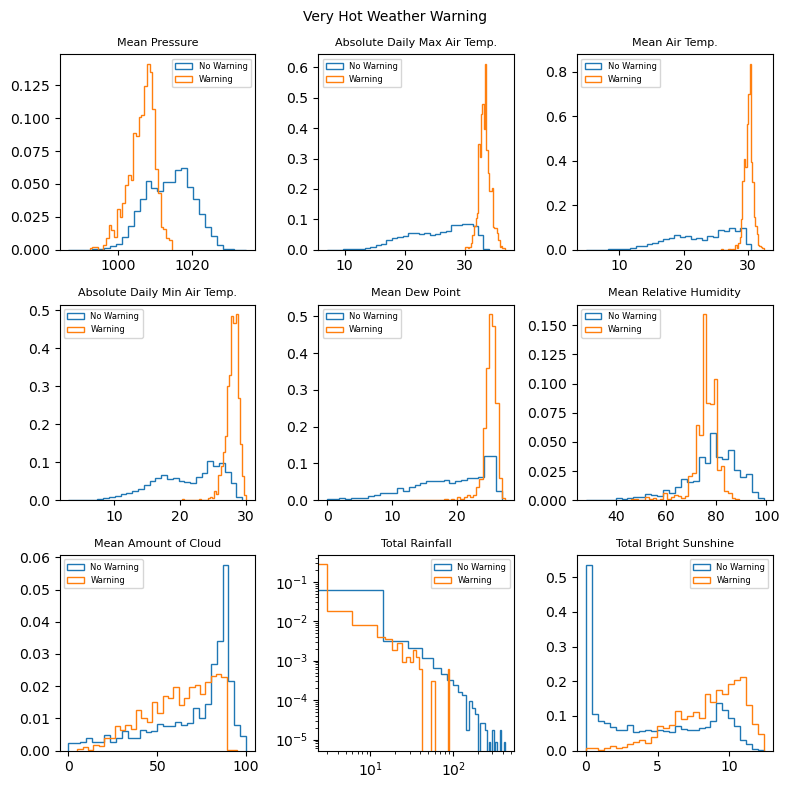

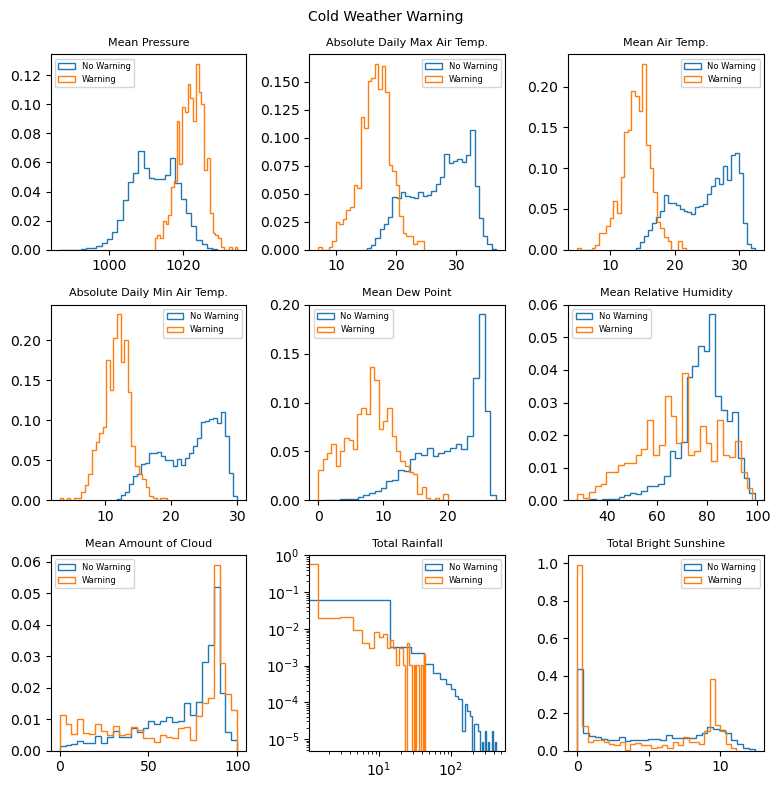

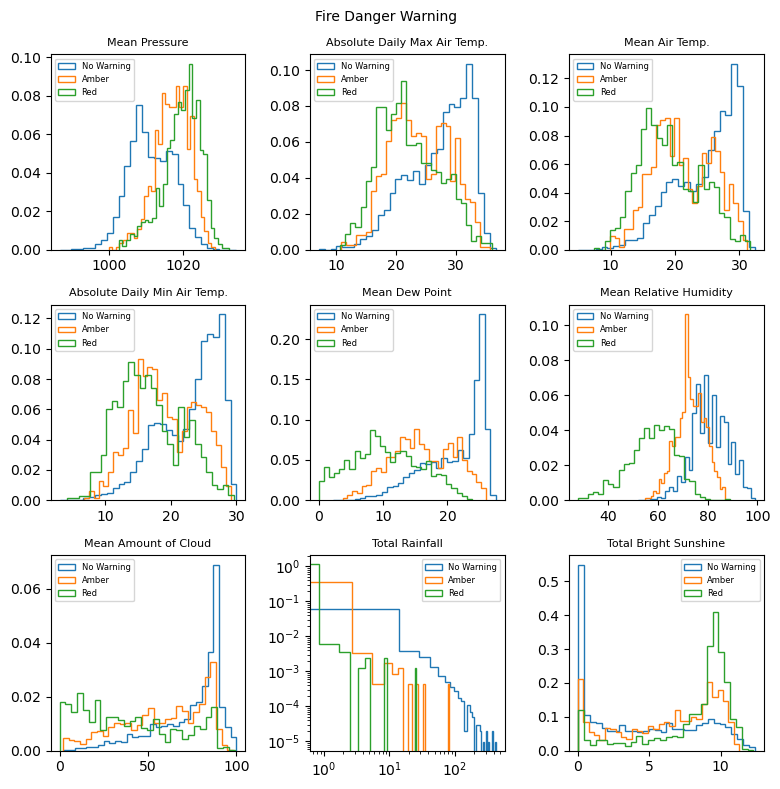

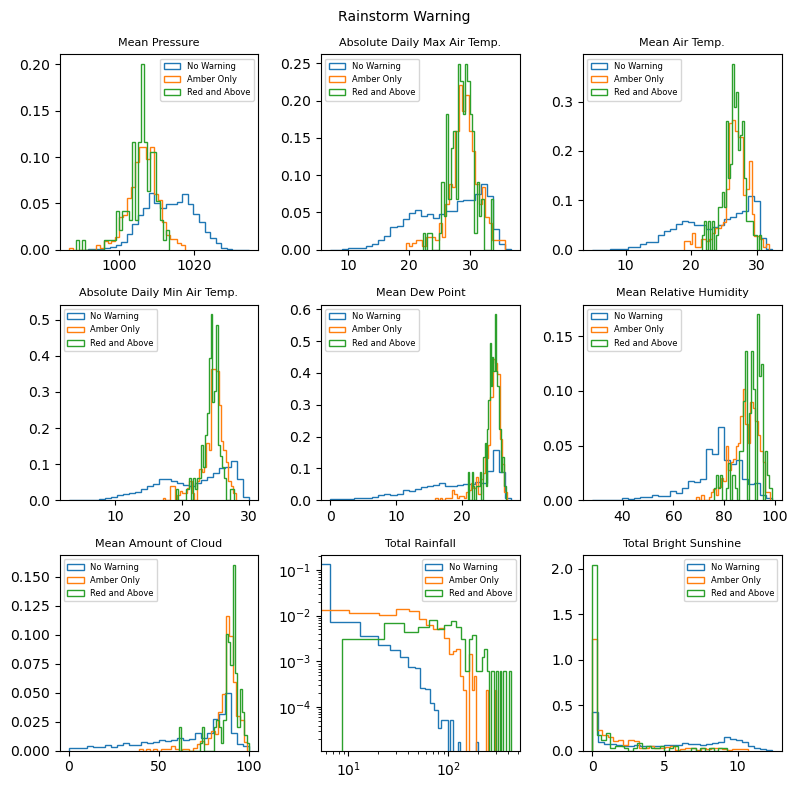

In [68]:
# part(d)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "hko_daily_weather_with_warnings_200011_202510.csv",
    parse_dates=["Date"]
)

vars_9 = [
    "Mean Pressure",
    "Absolute Daily Max Air Temp.",
    "Mean Air Temp.",
    "Absolute Daily Min Air Temp.",
    "Mean Dew Point",
    "Mean Relative Humidity",
    "Mean Amount of Cloud",
    "Total Rainfall",
    "Total Bright Sunshine",
]

def plot_warning_histograms(df, mask_dict, title):
    """
    mask_dict: {label: boolean mask}
    """
    fig, axes = plt.subplots(3, 3, figsize=(8, 8))
    axes = axes.flatten()

    for i, var in enumerate(vars_9):
        ax = axes[i]

        for label, mask in mask_dict.items():
            data = df.loc[mask, var].dropna()

            if len(data) == 0:
                continue

            ax.hist(
                data,
                bins=30,
                density=True,
                histtype="step",
                label=label,
            )

        # Rainfall log-log
        if var == "Total Rainfall":
            ax.set_xscale("log")
            ax.set_yscale("log")

        ax.set_title(var, fontsize=8)
        ax.legend(fontsize=6)

    fig.suptitle(title, fontsize=10)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_').lower()}_histograms.png", dpi=300)
    plt.show()

# Very Hot Weather Warning
mask_hot = {
    "No Warning": df["Very Hot Weather Warning"] == False,
    "Warning": df["Very Hot Weather Warning"] == True,
}

plot_warning_histograms(
    df,
    mask_hot,
    "Very Hot Weather Warning"
)

# Cold Weather Warning
mask_cold = {
    "No Warning": df["Cold Weather Warning"] == False,
    "Warning": df["Cold Weather Warning"] == True,
}

plot_warning_histograms(
    df,
    mask_cold,
    "Cold Weather Warning"
)

# Fire Danger Warning
mask_fire = {
    "No Warning": df["Fire Danger Warning"] == 0,
    "Amber": df["Fire Danger Warning"] == 1,
    "Red": df["Fire Danger Warning"] == 2,
}

plot_warning_histograms(
    df,
    mask_fire,
    "Fire Danger Warning"
)

# Rainstorm Warning
mask_rain = {
    "No Warning": df["Rainstorm Warning"] == 0,
    "Amber Only": df["Rainstorm Warning"] == 1,
    "Red and Above": df["Rainstorm Warning"] >= 2,
}

plot_warning_histograms(
    df,
    mask_rain,
    "Rainstorm Warning"
)


